In [2]:
import numpy as np
import pandas as pd
from collections import defaultdict

class StandardNaiveBayes:
    def __init__(self):
        self.prior_probabilities = {}
        self.conditional_probabilities = defaultdict(lambda: defaultdict(dict))
        self.classes = []
        self.features = []

    def fit(self, df, feature_columns, target_column):
        self.features = feature_columns
        self.classes = df[target_column].unique()
        total_samples = len(df)

        print("\n" + "="*80)
        print(" STANDARD NAIVE BAYES MATH BREAKDOWN (NO LAPLACE SMOOTHING)")
        print("="*80)

        # 1. Calculate Prior Probabilities P(C_i)
        print("\n[Step 1: Prior Probabilities P(C)]")
        for c in self.classes:
            class_count = len(df[df[target_column] == c])
            self.prior_probabilities[c] = class_count / total_samples
            print(f"  • P(class = '{c}') = {class_count} / {total_samples} = {self.prior_probabilities[c]:.4f}")

        # 2. Calculate Raw Conditional Probabilities P(X_j | C_i)
        print("\n[Step 2: Raw Conditional Probabilities P(Feature = Value | Class)]")
        for feature in self.features:
            unique_values = df[feature].unique()
            print(f"\n   Feature Column: '{feature}'")
            
            for c in self.classes:
                class_df = df[df[target_column] == c]
                total_class_count = len(class_df)
                
                for val in unique_values:
                    matching_count = len(class_df[class_df[feature] == val])
                    raw_prob = matching_count / total_class_count
                    self.conditional_probabilities[feature][c][val] = raw_prob
                    print(f"    - P({feature}='{val}' | class='{c}') = {matching_count} / {total_class_count} = {raw_prob:.4f}")

    def predict_single(self, sample_dict):
        """Calculates posterior probabilities using raw multiplications"""
        posteriors = {}
        for c in self.classes:
            probability = self.prior_probabilities[c]
            for feature, val in sample_dict.items():
                if feature in self.features:
                    cond_prob = self.conditional_probabilities[feature][c].get(val, 0.0)
                    probability *= cond_prob
            posteriors[c] = probability
        
        # Returns the class label with the highest score
        return max(posteriors, key=posteriors.get)

    def predict(self, df):
        """Generates predictions for an entire dataset dataframe"""
        predictions = []
        for _, row in df.iterrows():
            sample_dict = {feat: row[feat] for feat in self.features}
            predictions.append(self.predict_single(sample_dict))
        return np.array(predictions)


# ==========================================
# Performance Evaluation Metrics (From Scratch)
# ==========================================
def calculate_classification_report(y_true, y_pred):
    classes = np.unique(y_true)
    report = {}
    
    print("\n" + "="*80)
    print("📊 CLASSIFICATION PERFORMANCE METRICS REPORT (FROM SCRATCH)")
    print("="*80)
    print(f"{'Class':<12}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}")
    print("-" * 48)
    
    macro_precision = 0
    macro_recall = 0
    macro_f1 = 0
    
    for c in classes:
        # True Positives: Predicted Yes, Actual Yes
        tp = np.sum((y_true == c) & (y_pred == c))
        # False Positives: Predicted Yes, Actual No
        fp = np.sum((y_true != c) & (y_pred == c))
        # False Negatives: Predicted No, Actual Yes
        fn = np.sum((y_true == c) & (y_pred != c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        macro_precision += precision
        macro_recall += recall
        macro_f1 += f1
        
        print(f"{str(c):<12}{precision:<12.4f}{recall:<12.4f}{f1:<12.4f}")
        
    # Calculate Macro Averages across all targets
    num_classes = len(classes)
    macro_precision /= num_classes
    macro_recall /= num_classes
    macro_f1 /= num_classes
    
    # Accuracy is the global percentage of correct items
    accuracy = np.mean(y_true == y_pred)
    
    print("-" * 48)
    print(f"{'Accuracy':<36}{accuracy:.4f}")
    print(f"{'Macro Avg':<12}{macro_precision:<12.4f}{macro_recall:<12.4f}{macro_f1:<12.4f}")
    print("="*80 + "\n")


# ==========================================
# Execution Main Program
# ==========================================
if __name__ == "__main__":
    # Load dataset from the file
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    features = ["Age", "Income", "Student", "Credit_rating"]
    target = "class:buys_comp"

    # Initialize and train the raw classifier
    nb_classifier = StandardNaiveBayes()
    nb_classifier.fit(df, features, target)

    # 1. Generate predictions for the original rows to evaluate performance
    y_true = df[target].values
    y_pred = nb_classifier.predict(df)

    # 2. Output the performance evaluations report matrix
    calculate_classification_report(y_true, y_pred)


 STANDARD NAIVE BAYES MATH BREAKDOWN (NO LAPLACE SMOOTHING)

[Step 1: Prior Probabilities P(C)]
  • P(class = 'No') = 5 / 14 = 0.3571
  • P(class = 'Yes') = 9 / 14 = 0.6429

[Step 2: Raw Conditional Probabilities P(Feature = Value | Class)]

   Feature Column: 'Age'
    - P(Age='Y' | class='No') = 3 / 5 = 0.6000
    - P(Age='M' | class='No') = 0 / 5 = 0.0000
    - P(Age='S' | class='No') = 2 / 5 = 0.4000
    - P(Age='Y' | class='Yes') = 2 / 9 = 0.2222
    - P(Age='M' | class='Yes') = 4 / 9 = 0.4444
    - P(Age='S' | class='Yes') = 3 / 9 = 0.3333

   Feature Column: 'Income'
    - P(Income='High' | class='No') = 2 / 5 = 0.4000
    - P(Income='Medium' | class='No') = 2 / 5 = 0.4000
    - P(Income='Low' | class='No') = 1 / 5 = 0.2000
    - P(Income='High' | class='Yes') = 2 / 9 = 0.2222
    - P(Income='Medium' | class='Yes') = 4 / 9 = 0.4444
    - P(Income='Low' | class='Yes') = 3 / 9 = 0.3333

   Feature Column: 'Student'
    - P(Student='No' | class='No') = 4 / 5 = 0.8000
    - P(Stude


📐 MARKOV CHAIN STEP-BY-STEP TRANSITION SEQUENCE ANALYSIS
Full Sequential Chain Path: No ➔ No ➔ Yes ➔ Yes ➔ Yes ➔ No ➔ Yes ➔ No ➔ Yes ➔ Yes ➔ Yes ➔ Yes ➔ Yes ➔ No

[Step 1: Counting Observed State Transitions]
  • Transition 01: Customer 1 ('No') ➔ Customer 2 ('No')
  • Transition 02: Customer 2 ('No') ➔ Customer 3 ('Yes')
  • Transition 03: Customer 3 ('Yes') ➔ Customer 4 ('Yes')
  • Transition 04: Customer 4 ('Yes') ➔ Customer 5 ('Yes')
  • Transition 05: Customer 5 ('Yes') ➔ Customer 6 ('No')
  • Transition 06: Customer 6 ('No') ➔ Customer 7 ('Yes')
  • Transition 07: Customer 7 ('Yes') ➔ Customer 8 ('No')
  • Transition 08: Customer 8 ('No') ➔ Customer 9 ('Yes')
  • Transition 09: Customer 9 ('Yes') ➔ Customer 10 ('Yes')
  • Transition 10: Customer 10 ('Yes') ➔ Customer 11 ('Yes')
  • Transition 11: Customer 11 ('Yes') ➔ Customer 12 ('Yes')
  • Transition 12: Customer 12 ('Yes') ➔ Customer 13 ('Yes')
  • Transition 13: Customer 13 ('Yes') ➔ Customer 14 ('No')

Raw State Transition 

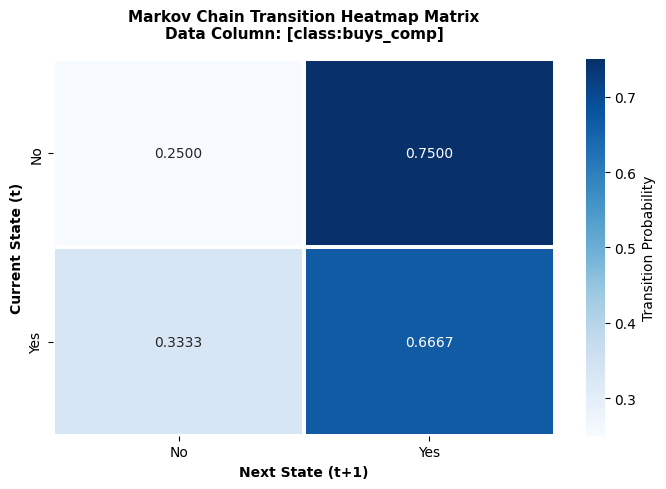

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class MarkovChainClassifier:
    def __init__(self):
        self.states = []
        self.transition_matrix = None
        self.state_to_idx = {}
        self.idx_to_state = {}
        self.transition_df = None

    def fit(self, df, sequence_column):
        # Extract the ordered sequence of events/decisions
        sequence = df[sequence_column].astype(str).tolist()
        self.states = sorted(list(set(sequence)))
        num_states = len(self.states)
        
        # Create map dictionaries between state names and matrix indices
        self.state_to_idx = {state: idx for idx, state in enumerate(self.states)}
        self.idx_to_state = {idx: state for idx, state in enumerate(self.states)}
        
        # Initialize count matrix with zeros
        counts = np.zeros((num_states, num_states))
        
        print("\n" + "="*80)
        print("📐 MARKOV CHAIN STEP-BY-STEP TRANSITION SEQUENCE ANALYSIS")
        print("="*80)
        print(f"Full Sequential Chain Path: {' ➔ '.join(sequence)}\n")
        
        # 1. Count consecutive transitions: State(t) -> State(t+1)
        print("[Step 1: Counting Observed State Transitions]")
        for i in range(len(sequence) - 1):
            current_state = sequence[i]
            next_state = sequence[i+1]
            
            row_idx = self.state_to_idx[current_state]
            col_idx = self.state_to_idx[next_state]
            
            counts[row_idx, col_idx] += 1
            print(f"  • Transition {i+1:02d}: Customer {i+1} ('{current_state}') ➔ Customer {i+2} ('{next_state}')")

        print("\nRaw State Transition Counts Matrix:")
        counts_df = pd.DataFrame(counts, index=self.states, columns=self.states)
        print(counts_df.to_string())

        # 2. Convert counts into row-normalized probabilities
        print("\n[Step 2: Normalizing to Transition Probabilities (Row Sums = 1.0)]")
        self.transition_matrix = np.zeros((num_states, num_states))
        
        for i, state_from in enumerate(self.states):
            row_total = np.sum(counts[i, :])
            if row_total > 0:
                self.transition_matrix[i, :] = counts[i, :] / row_total
                print(f"\n  • Out of {int(row_total)} transitions leaving State '{state_from}':")
                for j, state_to in enumerate(self.states):
                    print(f"    - P({state_from} ➔ {state_to}) = {int(counts[i, j])} / {int(row_total)} = {self.transition_matrix[i, j]:.4f}")
            else:
                self.transition_matrix[i, :] = 1.0 / num_states

        self.transition_df = pd.DataFrame(self.transition_matrix, index=self.states, columns=self.states)

    def print_matrix(self):
        print("\n" + "="*80)
        print("📊 FINAL MARKOV TRANSITION PROBABILITY MATRIX")
        print("="*80)
        print(self.transition_df.to_string())
        print("="*80 + "\n")


# ==========================================
# 2. Heatmap Visualization Function
# ==========================================
def plot_markov_heatmap(model, sequence_col):
    plt.figure(figsize=(7, 5))
    sns.heatmap(model.transition_df, annot=True, fmt=".4f", cmap="Blues", 
                linewidths=1.5, cbar_kws={'label': 'Transition Probability'})
    
    plt.title(f"Markov Chain Transition Heatmap Matrix\nData Column: [{sequence_col}]", 
              fontsize=11, pad=15, fontweight='bold')
    plt.ylabel("Current State (t)", fontsize=10, fontweight='bold')
    plt.xlabel("Next State (t+1)", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ==========================================
# Execution Main Program
# ==========================================
if __name__ == "__main__":
    # Load dataset from the CSV file
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    target_sequence_col = "class:buys_comp"

    # Initialize and run the Markov Chain model
    markov_model = MarkovChainClassifier()
    markov_model.fit(df, target_sequence_col)
    markov_model.print_matrix()

    # Render heatmap visualization
    plot_markov_heatmap(markov_model, target_sequence_col)